In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
cols = [
    'engine_displacement',
    'horsepower',
    'vehicle_weight',
    'model_year',
    'fuel_efficiency_mpg',
]
df = pd.read_csv('car_fuel_efficiency_2026.csv',usecols=cols)

EDA: df['fuel_efficiency_mpg'] doesn`t seem like having a long tail.

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

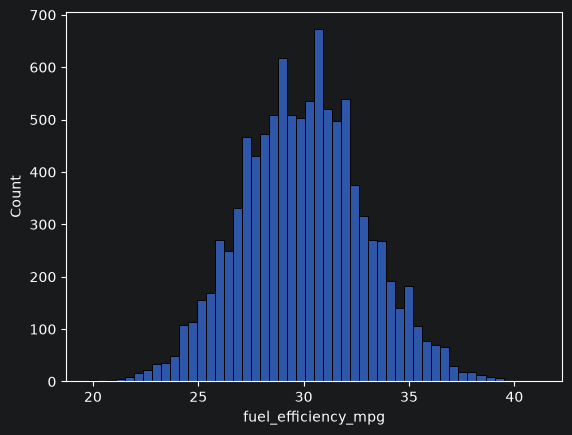

In [18]:
sns.histplot(df['fuel_efficiency_mpg'],bins=50)

Answer of Question 1: df['horsepower'] has missing value.

In [19]:
print(df.isna().any(axis=0))

model_year             False
engine_displacement    False
horsepower              True
vehicle_weight         False
fuel_efficiency_mpg    False
dtype: bool


Answer of Question 2: 254

In [20]:
print(df['horsepower'].median())

254.0


Prepare and split the dataset

In [21]:
import numpy as np
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

Answer of Question 3: Filling with mean value gives better RMSE.

In [27]:
def prepare_X(df,filling_values):
    df_num = df[base]
    df_num = df_num.fillna(filling_values)
    X = df_num.values
    return X

def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)

    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

base = [
    'engine_displacement',
    'horsepower',
    'vehicle_weight',
    'model_year',
]

X = prepare_X(df_train,0)
y_train = df_train['fuel_efficiency_mpg']
w0, w = train_linear_regression(X,y_train)
X_val = prepare_X(df_val,0)
y_pred = w0 + X_val.dot(w)
y_val = df_val['fuel_efficiency_mpg']
RMSE = rmse(y_val, y_pred)
print(f"RMSE (filling with 0): {round(RMSE,3)}")

X = prepare_X(df_train,df_train.mean())
y_train = df_train['fuel_efficiency_mpg']
w0, w = train_linear_regression(X,y_train)
X_val = prepare_X(df_val,df_val.mean())
y_pred = w0 + X_val.dot(w)
y_val = df_val['fuel_efficiency_mpg']
RMSE = rmse(y_val, y_pred)
print(f"RMSE (filling with mean value): {round(RMSE,3)}")


RMSE (filling with 0): 2.205
RMSE (filling with mean value): 2.202


Answer of Question 4: r=0 gives best RMSE

In [31]:
def train_linear_regression_reg(X, y, r):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX_r = X.T.dot(X) + r * np.eye(X.shape[1])
    XTX_r_inv = np.linalg.inv(XTX_r)

    w_full = XTX_r_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

r_all = [0, 0.01, 0.1, 1, 5, 10, 100]
for r in r_all:
    X = prepare_X(df_train,0)
    y_train = df_train['fuel_efficiency_mpg']
    w0, w = train_linear_regression_reg(X,y_train,r)
    X_val = prepare_X(df_val,0)
    y_pred = w0 + X_val.dot(w)
    y_val = df_val['fuel_efficiency_mpg']
    RMSE = rmse(y_val, y_pred)
    print(f"RMSE (with regularization coefficient r={r}): {round(RMSE,3)}")

RMSE (with regularization coefficient r=0): 2.205
RMSE (with regularization coefficient r=0.01): 2.206
RMSE (with regularization coefficient r=0.1): 2.224
RMSE (with regularization coefficient r=1): 2.349
RMSE (with regularization coefficient r=5): 2.409
RMSE (with regularization coefficient r=10): 2.419
RMSE (with regularization coefficient r=100): 2.429


Answer of Question 5: 0.029

In [34]:
seeds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
RMSEs = []

for seed in seeds:
    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train + n_val]]
    df_test = df.iloc[idx[n_train + n_val:]]

    X = prepare_X(df_train,0)
    y_train = df_train['fuel_efficiency_mpg']
    w0, w = train_linear_regression(X,y_train)
    X_val = prepare_X(df_val,0)
    y_pred = w0 + X_val.dot(w)
    y_val = df_val['fuel_efficiency_mpg']
    RMSE = rmse(y_val, y_pred)
    RMSEs.append(RMSE)

print(f"std = {round(np.array(RMSEs).std(),3)}")

std = 0.029


Answer of Question 6: 2.236

In [36]:
np.random.seed(9)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

X = prepare_X(df_train,0)
y_train = df_train['fuel_efficiency_mpg']
w0, w = train_linear_regression_reg(X,y_train, 0.001)
X_test = prepare_X(df_test,0)
y_pred = w0 + X_test.dot(w)
y_test = df_test['fuel_efficiency_mpg']
RMSE = rmse(y_test, y_pred)
print(f"RMSE on the test dataset: {round(RMSE,3)}")


RMSE on the test dataset: 2.236
